# Gradient Boosting Regressor (GBR)

Author: Pete King

We test the performance of an ensemble decision tree based on the concept of gradient boosting, where many weak learners are combined to provide predictions that are less likely to overfit to training data.  Compared to time series methods like ARIMA and the LSTM deep-learning model, the GBR estimator assumes no relationship between observations at different timestamps -- a disadvantage when forecasting time-series data.  However, the GBR retains an advantage over a linear model like ElasticNet because it can deal with non-linear relationships in the data.

In this project, we examine how well such a model can predict future volatility for an ETF over a moderate horizon, given a feature vector of market, macroeconomic, and other financial variables.  Specifically, each observation is a feature vector (**x_t**) that contains the daily return for the ETF, its near-term historic volatility, and other features at time **t** (a daily observation).  The label (**y_t**) is the mid-term future volatility, which we computed earlier using a rolling window.

Unlike other classic machine learning estimators, the GBR estimator works as a decision tree and does not require us to standardize our input features.

In [1]:
#123456789012345678901234567890123456789012345678901234567890123456789012345678
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    make_scorer,
    r2_score,
    mean_absolute_error,
    root_mean_squared_error,
    mean_squared_error
)
from sklearn.model_selection import (
    TimeSeriesSplit,
    GridSearchCV
)
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.tree import plot_tree

import data_prep as dp

DATA_FOLDER = 'data/train-val-test/'
TRAIN_DATA_FILE = DATA_FOLDER + 'train_ALL_DATA.csv'
VAL_DATA_FILE = DATA_FOLDER + 'val_ALL_DATA.csv'
TICKER = 'SPY'

## I. Import data

We have already split our data into training and validation sets.  We reserve the held-out validation set (val_df) to plot predictions for comparisons against other models, but we further divide the training set into cross-validation folds to take advantage of scikit-learn's [TimeSeriesSplit](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html) function.  This gives us an easy way to apply scikit-learn's standard cross-validation (CV) methods for hyperparameter optimization while preserving chronological order between training and validation subsets within CV folds.

In [2]:
train_df = pd.read_csv(
    TRAIN_DATA_FILE,
    index_col='date',
    parse_dates=True
)
val_df = pd.read_csv(
    VAL_DATA_FILE,
    index_col='date',
    parse_dates=True
)

In [3]:
# Separate features from labels
data_cols, _ = dp.get_X_y_cols(train_df)
label_col = [TICKER + '_f-vol_target']
# Training set
X_train = train_df.dropna()[data_cols].astype(np.float32)
y_train = train_df.dropna()[label_col].astype(np.float32).values.reshape(-1,)
# Validation set
X_val = val_df.dropna()[data_cols].astype(np.float32)
y_val = val_df.dropna()[label_col].astype(np.float32).values.reshape(-1,)
# Define time series cross-validation split
ts_cv = TimeSeriesSplit(
    n_splits=3,
    test_size=252,
    gap=63
)

## II. Define model, fit to data, and evaluate performance

In [4]:
# Define model, metrics, and Grid Search for hyperparameter tuning
reg = GradientBoostingRegressor(
    loss='absolute_error',
    learning_rate=0.01,
    max_features='sqrt',
    max_depth=2,
    n_estimators= 1000
)

In [5]:
reg.fit(X_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'absolute_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.01
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",1000
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",2
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in thele

### Visualize performance; Check evaluation metrics

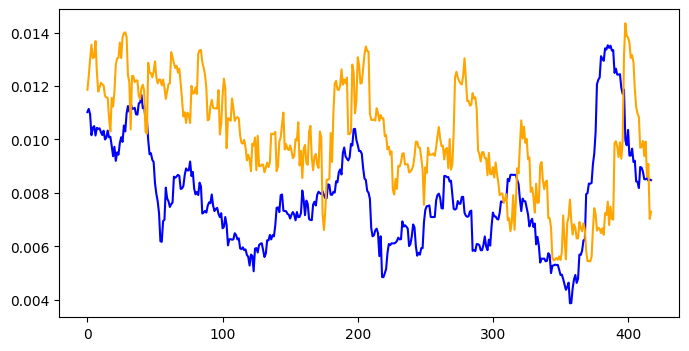

In [6]:
# Use the best estimator to make predictions on the validation set
# best = reg.best_estimator_
preds = reg.predict(X_val)
x = range(len(y_val))

fig = plt.figure(figsize=(8, 4))
ax = fig.subplots()

ax.plot(x, y_val, color='blue')
ax.plot(x, preds, color='orange')

In [7]:
print(f'MAE: {mean_absolute_error(y_val, preds)}')
print(f'R2: {r2_score(y_val, preds)}')

MAE: 0.0028320930715950315
R2: -1.718186739256402


Much like with the Ridge regression, we see that the GBR's predictions tends to follow the general trend of future volatility, but with a pronounced lag.  Overestimation of volatility is present but less pronounced than we saw with Ridge regression.

Here R-squared is not much above zero -- better than it was for Ridge but still not ideal.

## III. Inspect model

In part we chose a decision tree based model because the implementations in scikit-learn give us an easy way to understand which features are most important in its decision-making process.  Let's take a look and see which features have been most important for our GBR.

In [8]:
feature_importances = list(
    zip(reg.feature_names_in_, reg.feature_importances_)
)
for feature, coef in sorted(feature_importances, key=lambda i: -i[1]):
    print(f'{feature}: {coef:2.3f}')

^VIX: 0.095
real_GDP_chg: 0.090
XLY_h-vol: 0.066
^VXN: 0.059
debt_to_GDP_chg: 0.050
XLK_h-vol: 0.034
core_PCE_chg: 0.032
unemployment_rate_chg: 0.030
XLE_h-vol: 0.030
SPY_h-vol: 0.030
female_unemployment_rate_chg: 0.028
LQD_h-vol: 0.026
^MOVE: 0.025
XLRE_h-vol: 0.022
BND_h-vol: 0.022
QQQ_h-vol: 0.019
^GSPC_h-vol: 0.019
debt_interest_chg: 0.019
nominal_GDP_chg: 0.019
average_duration_of_unemployment_chg: 0.018
core_PCI_chg: 0.017
IWM_h-vol: 0.017
TIP_h-vol: 0.017
teenager_unemployment_rate_chg: 0.015
XLI_h-vol: 0.015
NG=F_h-vol: 0.015
IEF_h-vol: 0.014
SHY_h-vol: 0.013
XLF_h-vol: 0.013
XLB_h-vol: 0.012
consumer_price_index_chg: 0.012
producer_price_index_chg: 0.011
BIL_h-vol: 0.011
GLD_h-vol: 0.010
XLV_h-vol: 0.008
HYG_h-vol: 0.008
XLP_h-vol: 0.008
TLT_h-vol: 0.006
^FTSE_h-vol: 0.006
male_unemployment_rate_chg: 0.005
HG=F_h-vol: 0.005
personal_consumption_expenditure_chg: 0.005
^HSI_h-vol: 0.005
GC=F_h-vol: 0.004
adult_unemployment_rate_chg: 0.004
CL=F_h-vol: 0.003
continued_jobless_clai

Similar to the Ridge regressor, we see nuanced contributions from nearly all the features, reflecting the complex dynamics of financial markets.  The market volatility indexes (VIX and VXN) once again rank high in feature importance, along with the recent historical volatility of the asset itself (SPY_h-vol).

This is what we expected and confirms that the model is paying attention to what we believe are the right signals.